# **Telecom X2 Challenge**

Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.



In [3]:
# carga de datos desde github

import pandas as pd

datos = pd.read_csv('/content/Telecom_X2_datos.csv')
#Telecom_X2_datos.csv
datos

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.156476
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.969099
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.429323
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.221565
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.758054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.812952
7039,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.797502
7040,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.653517
7041,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.230440


In [4]:
# eliminar columna customerID

datos = datos.drop('customerID', axis=1)

datos

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.156476
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.969099
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.429323
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.221565
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.758054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,Female,0,0,0,13,1,0,DSL,1,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.812952
7039,1,Male,0,1,0,22,1,1,Fiber optic,0,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.797502
7040,0,Male,0,0,0,2,1,0,DSL,0,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.653517
7041,0,Male,0,1,1,67,1,0,DSL,1,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.230440


## **Análisis Dirigido**

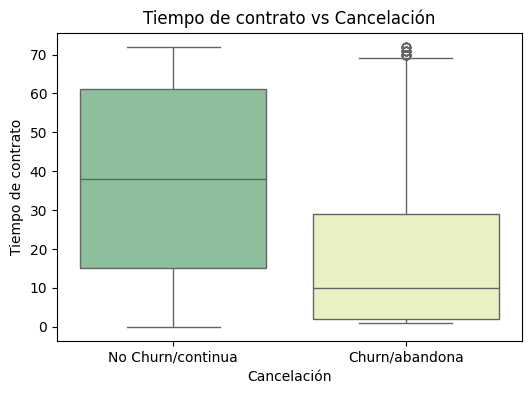

In [50]:
#Tiempo de contrato (ternure) vs cancelación (churn)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

valores_churn = datos['Churn'].map({0:'No Churn/continua',1:'Churn/abandona'})

plt.figure(figsize = (6,4))
sns.boxplot(data = datos, x = valores_churn,
            y = 'customer.tenure',
            hue = valores_churn,
            palette = ['#85C79A', '#EDF7BD'],
            )


plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Tiempo de contrato')
plt.savefig('graf1.png', dpi=300, bbox_inches='tight')
plt.show()

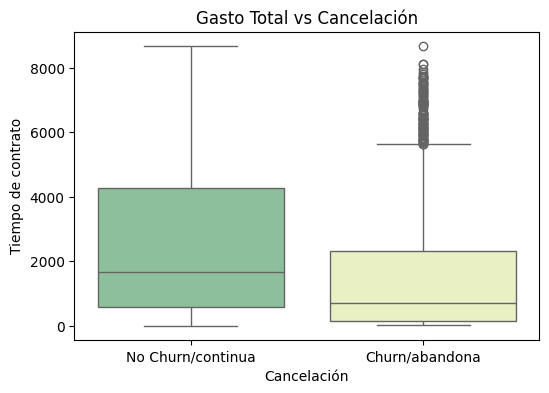

In [51]:
#Gasto total vs cancelación

import matplotlib.pyplot as plt
import seaborn as sns

valores_churn = datos['Churn'].map({0:'No Churn/continua',1:'Churn/abandona'})

plt.figure(figsize = (6,4))
sns.boxplot(data = datos, x = valores_churn,
            y = 'account.Charges.Total',
            hue = valores_churn,
            palette = ['#85C79A', '#EDF7BD'],
            )
plt.title('Gasto Total vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Tiempo de contrato')
plt.savefig('graf2.png', dpi=300, bbox_inches='tight')
plt.show()

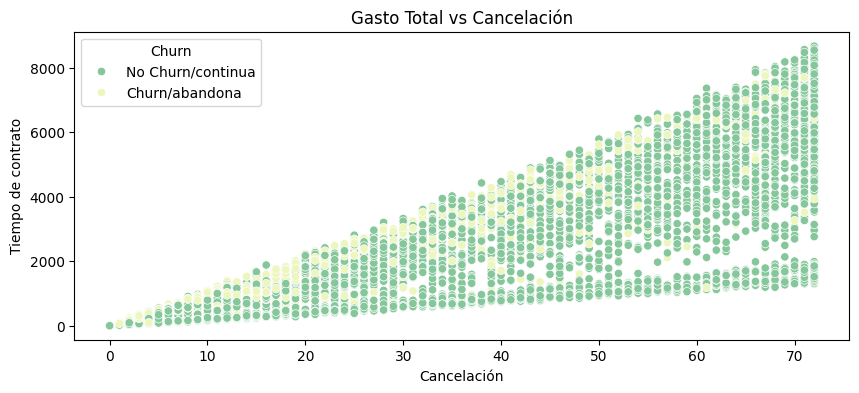

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

valores_churn = datos['Churn'].map({0:'No Churn/continua',1:'Churn/abandona'})

plt.figure(figsize = (10,4))
sns.scatterplot(data = datos, x = 'customer.tenure',
            y = 'account.Charges.Total',
            hue = valores_churn,
            palette = ['#85C79A', '#EDF7BD'],
            )
plt.title('Gasto Total vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Tiempo de contrato')
plt.savefig('graf3.png', dpi=300, bbox_inches='tight')
plt.show()

De los gráficos podemos indicar que:
* Los clientes que cancelan tienden a tener pocos meses de contrato.
* Existe una relación directa entre: Mayor tiempo de contrato -> Mayor gasto total -> Menor probabilidad de churn.

## **Variables EXPLICATIVAS y RESPUESTA**

In [12]:
# separar variables explicativas de la variable de respuesta.
# La variable de respuesta es la columna "Churn"

X = datos.drop('Churn', axis = 1)
y = datos['Churn']

In [13]:
X.head(2)

,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.156476
1,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,1.969099


In [14]:
y

,Churn
0,0
1,0
2,1
3,1
4,1
...,...
7038,0
7039,1
7040,0
7041,0


## **Transformando la variable RESPUESTA**

codificar "y" con LabelEncoder()

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = pd.Series(label_encoder.fit_transform(y)) #la serie y en serie


## **Verificación de la Proporción de Cancelación (Churn)**

In [16]:
y.value_counts()

,count
0,5174
1,1869


In [17]:
y.value_counts(normalize = True)

,proportion
0,0.73463
1,0.26537


In [18]:
y

,0
0,0
1,0
2,1
3,1
4,1
...,...
7038,0
7039,1
7040,0
7041,0


In [19]:
columnas = X.columns

**Variables CATEGÓRICAS**

- customer.gender
- customer.SeniorCitizen
- customer.Partner
- customer.Dependents
- phone.PhoneService
- phone.MultipleLines
- internet.InternetService
- internet.OnlineSecurity
- internet.DeviceProtection
- internet.TechSupport
- internet.StreamingTV
- internet.StreamingMovies
- account.Contract
- account.PaperlessBilling
- account.PaymentMethod



In [20]:
variables_categoricas = [
    "customer.gender",
    "customer.SeniorCitizen",
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "phone.MultipleLines",
    "internet.InternetService",
    "internet.OnlineSecurity",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies",
    "account.Contract",
    "account.PaperlessBilling",
    "account.PaymentMethod"
]


**Variables NUMÉRICAS**

- customer.tenure
- account.Charges.Monthly
- account.Charges.Total
- Cuentas_Diarias

In [21]:
variables_numericas = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total",
    "Cuentas_Diarias"
]

In [22]:
# Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning.
# método de codificación "one-hot encoding".

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

cod_one_hot = make_column_transformer((OneHotEncoder(drop = 'if_binary'), ['customer.gender', 'internet.InternetService',
                                  'account.Contract', 'account.PaymentMethod']),
                                  remainder= 'passthrough',
                                  sparse_threshold= 0,
                                  force_int_remainder_cols= False)



In [23]:
# Se ajusta con TODO el dataset (menos la columna objetivo)
cod_one_hot.fit(datos.drop('Churn', axis=1))

# Se transforma TODO el dataset
datos_encoded = cod_one_hot.transform(datos.drop('Churn', axis=1))

#Recuperar los nombres de las columnas
nombres_columnas = cod_one_hot.get_feature_names_out()


In [24]:
#crear el data frame con los nombres correctos
X = pd.DataFrame(datos_encoded, columns = nombres_columnas)

#variable objetivo
y = datos['Churn']

## **Correlación**

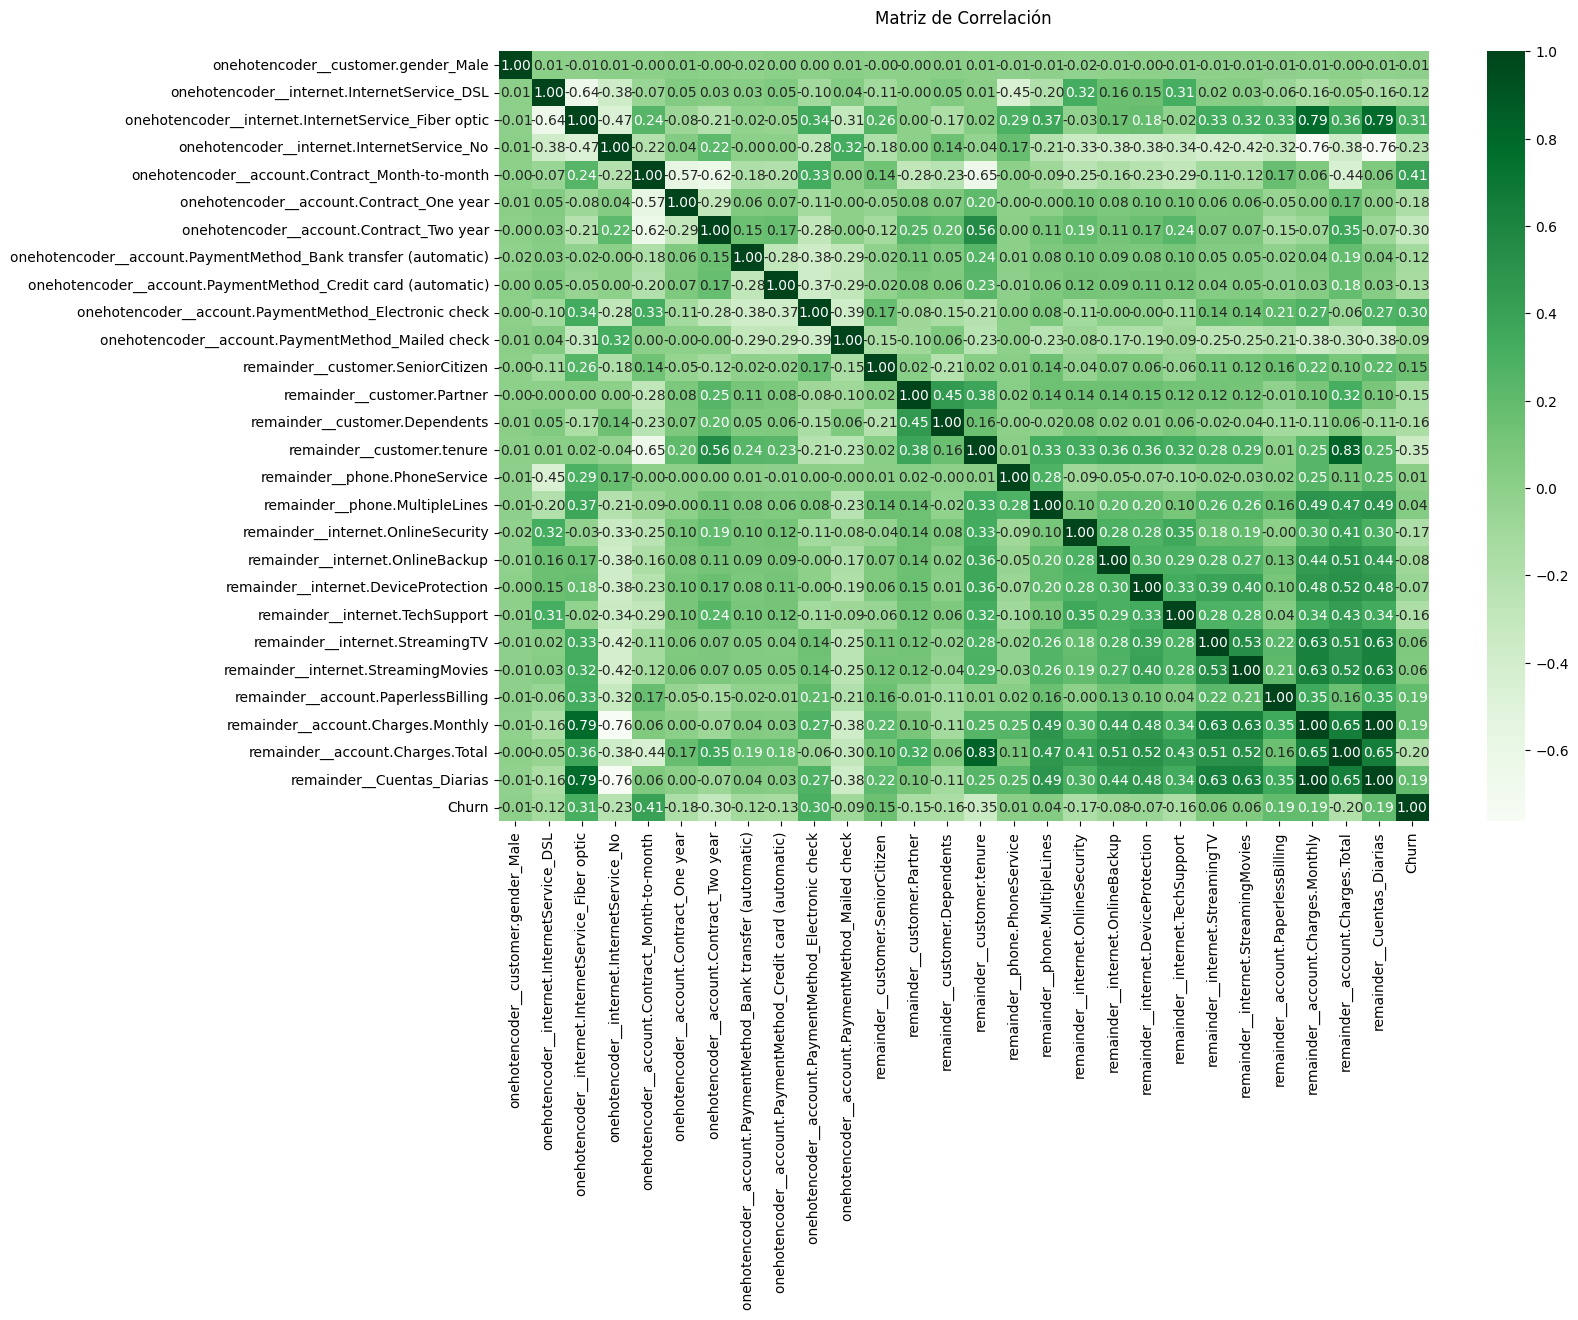

,Churn
Churn,1.000000
onehotencoder__account.Contract_Month-to-month,0.405103
onehotencoder__internet.InternetService_Fiber optic,0.308020
onehotencoder__account.PaymentMethod_Electronic check,0.301919
remainder__account.Charges.Monthly,0.193356
remainder__Cuentas_Diarias,0.193356
remainder__account.PaperlessBilling,0.191825
remainder__customer.SeniorCitizen,0.150889
remainder__internet.StreamingTV,0.063228
remainder__internet.StreamingMovies,0.061382


In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
#annot = True- las etiquetas en cada cuadro / fmt = ".2f" - los decimales de las anotaciones
sns.heatmap(pd.concat([X, y], axis = 1).corr(), cmap='Greens', annot = True, fmt = ".2f")
plt.title("Matriz de Correlación", pad=20)

plt.show()

pd.concat([X, y], axis=1).corr()['Churn'].sort_values(ascending=False)

La matriz de correlación indica que cada variable tiene una correlación perfecta consigo misma, es decir 1.0

* Bloques rojos - correlación positiva fuerte.

* Bloques azules - correlación negativa fuerte.

* Bloques blancos - casi sin relación.

In [29]:
# Separar los datos de prueba de los datos de entrenamiento

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 5)

y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.73457
1,0.26543


**Esto demuestra que existe desbalance.**

Se requiere usar oversampling aleatorio, oversampling SMOTE o undersampling.

## **Normalización**

In [30]:
#Para la normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

## **Balanceo**

**Oversampling Aleatorio**

In [31]:
from imblearn.over_sampling import RandomOverSampler

over_sampling_aleatorio = RandomOverSampler(random_state=5)
X_train_over, y_train_over = over_sampling_aleatorio.fit_resample(X_train_scaler, y_train)

y_train_over.value_counts()


,count
Churn,
0,3880
1,3880


In [32]:
y_train_over.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


- Confirma que el oversampling se aplicó correctamente.
  * La clase minoritaria (1 - Abandono la empresa) fue aumentada hasta igualar a la mayoritaria.
  * Ahora ambas clases tienen la misma cantidad de ejemplos.

**Oversampling SMOTE**

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaler, y_train)

y_train_smote.value_counts()

,count
Churn,
0,3880
1,3880


In [34]:
y_train_smote.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


El **Oversampling Aleatorio y SMOTE** generaron **el mismo resultado**.  Esto indica que **la clase minoritaria no tiene suficiente variabilidad** para que SMOTE genere puntos sintéticos distintos.


**Undersampling**

In [35]:
from imblearn.under_sampling import RandomUnderSampler

under_sampling = RandomUnderSampler(random_state = 5)
X_train_under, y_train_under = under_sampling.fit_resample(X_train_scaler, y_train)

y_train_under.value_counts()

,count
Churn,
0,1402
1,1402


In [36]:
y_train_under.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


- Confirma que el undersampling se aplicó correctamente.
  * La clase mayoritaria (0 - continua en la empresa) fue reducida hasta igualar a la minoritaria.
  * Ahora ambas clases tienen la misma cantidad de ejemplos.

## **DummyClassifier**

Accuracy: 0.7348097671777399
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1294
           1       0.00      0.00      0.00       467

    accuracy                           0.73      1761
   macro avg       0.37      0.50      0.42      1761
weighted avg       0.54      0.73      0.62      1761

[[1294    0]
 [ 467    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


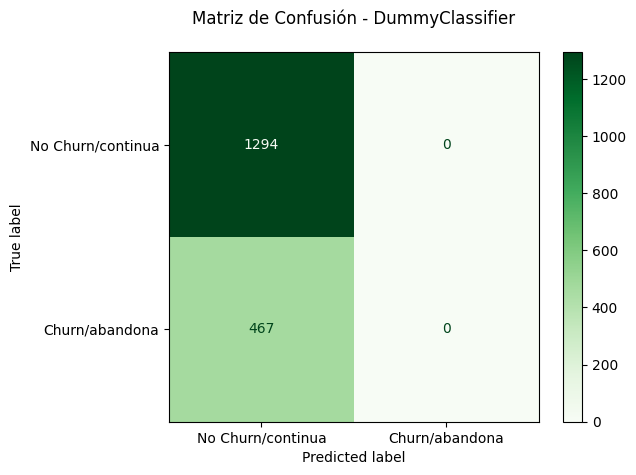

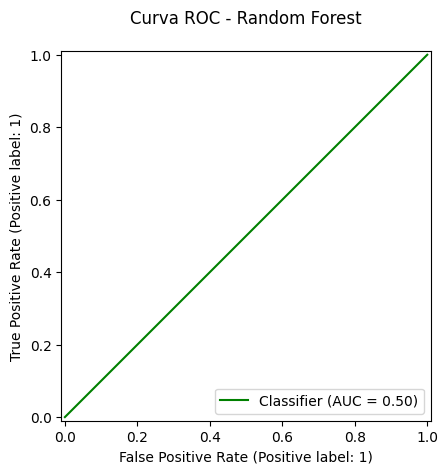

In [57]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

dummy = DummyClassifier(strategy = 'most_frequent')
dummy.fit(X_train_scaler, y_train)

y_pred_dummy = dummy.predict(X_test_scaler)

#Accuracy - qué porcentaje fueron correctas?
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
#Recall - cuántos clientes que sí se iban se detectaron
#F1 - qué tan equilibrado está el modelo entre precisión y recall
print(classification_report(y_test, y_pred_dummy))
#Falsos negativos - clientes que sí se iban y el modelo no detecto
print(confusion_matrix(y_test, y_pred_dummy))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_dummy)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['No Churn/continua', 'Churn/abandona'])

visualizacion_dummy.plot(cmap='Greens', values_format='d')
plt.title("Matriz de Confusión - DummyClassifier", pad = 20)
plt.show()

#probabilidad curva ROC
y__pred_dummy_proba = dummy.predict_proba(X_test_scaler)[:,1]

#Curva ROC del modelo Random Forest
RocCurveDisplay.from_predictions(y_test, y__pred_dummy_proba, color = 'green')
plt.title('Curva ROC - Random Forest', pad = 20)
plt.savefig('graf5.png', dpi=300, bbox_inches='tight')
plt.show()


* Accuracy del 73 % para clientes que no se van de la empresa

* Cada vez que el Dummy predice “No Churn”, acierta el 73%.

* Detecta TODOS los “No Churn” (recall = 1.00)

* Matriz de confusión:
  - 1294 verdaderos negativos - se predice "No churn" y fueron "No churn".

  - 0 falsos negativos - nunca predijo "churn".

  - 467 falsos negativos - se predijo "No churn" que se quedaban, pero eran "churn".

  - 0 verdaderos positivos - no detectó ningun "churn"

  **Curva ROC**

AUC = 0.50

El modelo tiene un 50% de probabilidad de asignar puntuación más alta a un cliente que sí abandona a uno que no abandona.

Detalles:
  - 1.0 -> modelo perfecto
  - 0.5 -> modelo aleatorio
  - 0.28 -> modelo peor que aleatorio.

Si cualquier modelo detecta aunque sea 1 churn se superara el dummy.

## **Modelos para comparación**

### Regresión Logística

Accuracy: 0.7348097671777399
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1294
           1       0.54      0.78      0.64       467

    accuracy                           0.77      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.77      0.78      1761



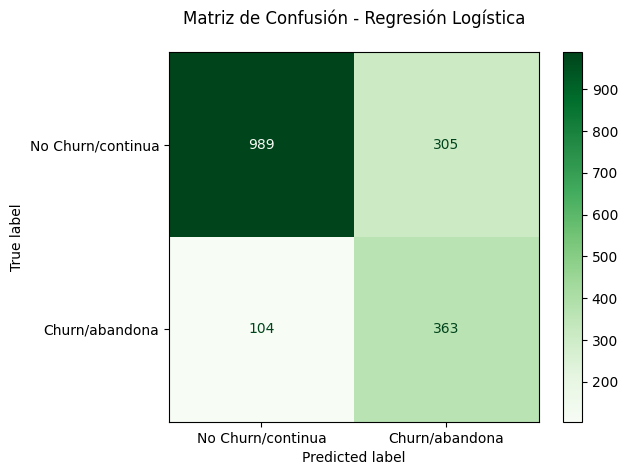

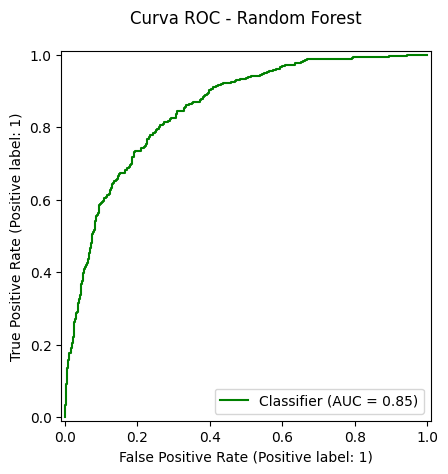

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Crea el modelo
reg_log = LogisticRegression(max_iter = 2000, class_weight = None)

#Entrenar el modelo
reg_log.fit(X_train_smote, y_train_smote)

#Predecir
y_pred_reg_log = reg_log.predict(X_test_scaler)

#Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_reg_log))

#Matriz de confusión
cm = confusion_matrix(y_test, y_pred_reg_log)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['No Churn/continua', 'Churn/abandona'])

#Gráfico
visualizacion_dummy.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusión - Regresión Logística', pad = 20)
plt.show()

# probabilidad de clase 1 (Churn)
y_reg_log_proba = reg_log.predict_proba(X_test_scaler)[:, 1]

#Curva ROC del modelo Random Forest
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_reg_log_proba, color = 'green')
plt.title('Curva ROC - Random Forest', pad = 20)
plt.savefig('graf6.png', dpi=300, bbox_inches='tight')
plt.show()


**El modelo Regresión Logística:**

Tiene exactitud del 73 %, pero predijo casi todo como "churn".

No Churn/continua = 0
Churn/abandona = 1

- 989 clientes que realmente no abandonan.

- 363 clientes que realmente abandonan.

- 305 clientes que se predice abandonan, pero en realidad permanecen. **FALSOS POSITIVO.**

- 104 clientes que se predicen que permanecen, pero en realidad abandonan. **FALSOS NEGATIVOS.**

**Curva ROC**

AUC = 0.85

El modelo tiene un 85% de probabilidad de asignar puntuación más alta a un cliente que sí abandona a uno que no abandona.

Detalles:
  - 1.0 -> modelo perfecto
  - 0.5 -> modelo aleatorio
  - 0.28 -> modelo peor que aleatorio.

###Random Forest

Accuracy: 0.7932992617830777
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1294
           1       0.61      0.60      0.61       467

    accuracy                           0.79      1761
   macro avg       0.73      0.73      0.73      1761
weighted avg       0.79      0.79      0.79      1761



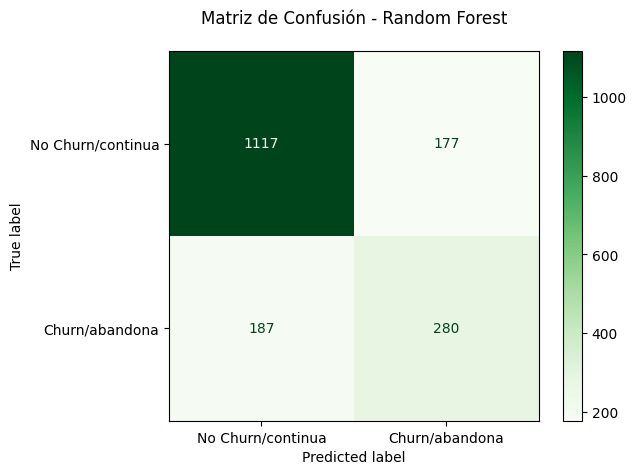

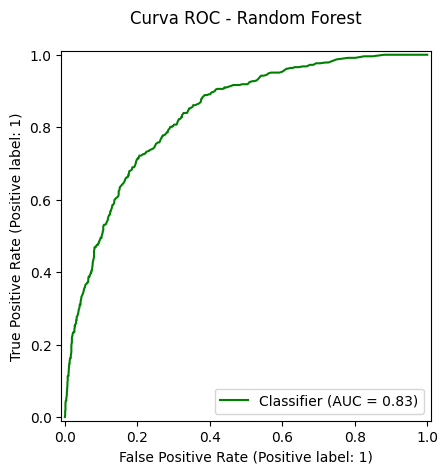

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Crea el modelo
random_forest = RandomForestClassifier(n_estimators = 300,
                                       max_depth = None,
                                       min_samples_split = 2,
                                       min_samples_leaf = 1,
                                       random_state = 5,
                                       n_jobs = -1)

#Entrenar el modelo
random_forest.fit(X_train_smote, y_train_smote)

#Predecir
y_pred_random_forest = random_forest.predict(X_test_scaler)

#Métricas
print('Accuracy:', accuracy_score(y_test, y_pred_random_forest))
print(classification_report(y_test, y_pred_random_forest))

#Matriz de confusión

cm = confusion_matrix(y_test, y_pred_random_forest)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['No Churn/continua', 'Churn/abandona'])

#Gráfico
visualizacion_dummy.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusión - Random Forest', pad = 20)
plt.show()

# probabilidad de clase 1 (Churn)
y_random_forest_proba = random_forest.predict_proba(X_test_scaler)[:, 1]

#Curva ROC del modelo Random Forest
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_random_forest_proba, color = 'green')
plt.title('Curva ROC - Random Forest', pad = 20)
plt.savefig('graf7.png', dpi=300, bbox_inches='tight')
plt.show()

* 1117 clientes que continuan y el modelo predijo que permanecian.

* 280 clientes que abandonaron y el modelo predijo que abandonaban.

* 177 clientes que continuaron y el modelo predijo que abandonaban. **FALSOS POSITIVOS.**

* 187 clientes que abandonaron y el modelo predijo que continuaban. **FALSOS NEGATIVOS.**

**El modelo Random Forest:**
* Es bueno detectando clientes que permanecen.
* Es moderado para detectar clientes que abandonan "churn".
* Tiene una exactitud del 79%.

**Curva ROC**

AUC = 0.83

El modelo tiene un 83% de probabilidad de asignar puntuación más alta a un cliente que sí abandona a uno que no abandona.

El modelo Random Forest es el mejor modelo al momento.

Detalles:
  - 1.0 -> modelo perfecto
  - 0.5 -> modelo aleatorio
  - 0.28 -> modelo peor que aleatorio.


###Decision Tree

Accuracy: 0.8023850085178875
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1294
           1       0.63      0.61      0.62       467

    accuracy                           0.80      1761
   macro avg       0.75      0.74      0.74      1761
weighted avg       0.80      0.80      0.80      1761



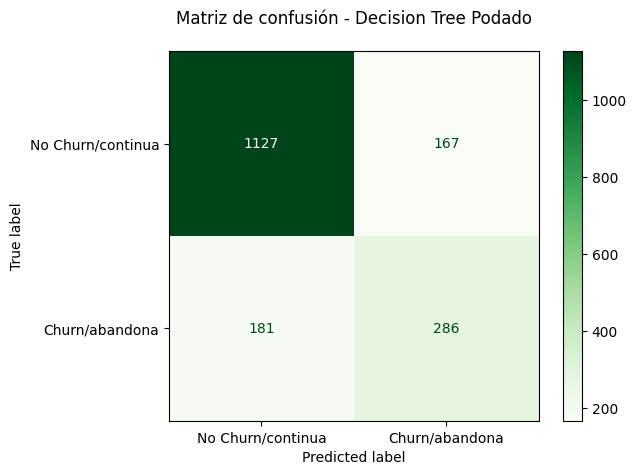

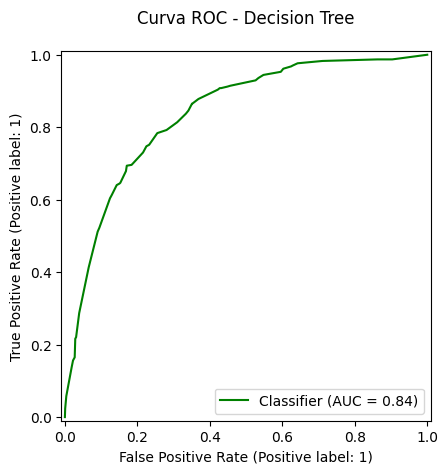

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

#Entrenar árbol de decisión podado
arbol_decision = DecisionTreeClassifier(max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=5
)

arbol_decision.fit(X_train_scaler, y_train)

#prediccion
y_arbol_decision = arbol_decision.predict(X_test_scaler)

#Métricas
print('Accuracy:', accuracy_score(y_test, y_arbol_decision))
print(classification_report(y_test, y_arbol_decision))

#Matriz de confusión
cm = confusion_matrix(y_test, y_arbol_decision)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['No Churn/continua', 'Churn/abandona'])

#Gráfico
visualizacion_dummy.plot(cmap = 'Greens')
plt.title('Matriz de confusión - Decision Tree Podado', pad = 20)
plt.show()

#probabilidad curva ROC
y_arbol_decision_proba = arbol_decision.predict_proba(X_test_scaler)[:, 1]

#Curva ROC
RocCurveDisplay.from_predictions(y_test, y_arbol_decision_proba, color = 'green')
plt.title('Curva ROC - Decision Tree', pad = 20)
plt.savefig('graf8.png', dpi=300, bbox_inches='tight')
plt.show()

* Tiene una exactitud del 80
%

* 1127 clientes que continuan y el modelo predijo que permanecian.

* 286 clientes que abandonaron y el modelo predijo que abandonaban.

* 167 clientes que continuaron y el modelo predijo que abandonaban. **FALSOS POSITIVOS.**

* 181 clientes que abandonaron y el modelo predijo que continuaban. **FALSOS NEGATIVOS.**


**Curva ROC**

AUC = 0.84

El modelo tiene un 84% de probabilidad de asignar puntuación más alta a un cliente que sí abandona a uno que no abandona.

Detalles:
  - 1.0 -> modelo perfecto
  - 0.5 -> modelo aleatorio
  - 0.28 -> modelo peor que aleatorio.


###XGBoost

In [ ]:
# instalar xgboost
!pip install xgboost

Accuracy: 0.8006814310051107
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1294
           1       0.66      0.51      0.57       467

    accuracy                           0.80      1761
   macro avg       0.75      0.71      0.72      1761
weighted avg       0.79      0.80      0.79      1761



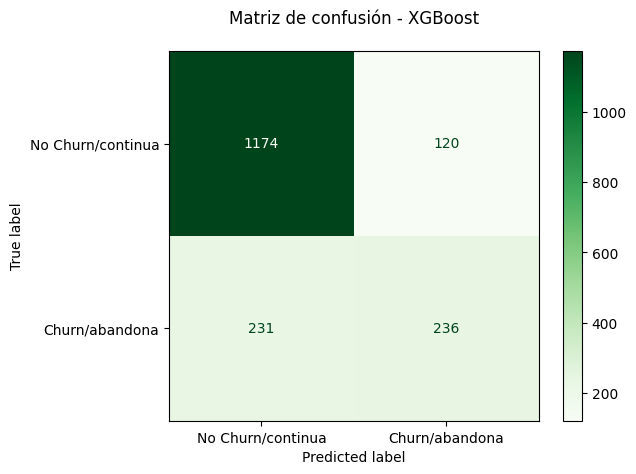

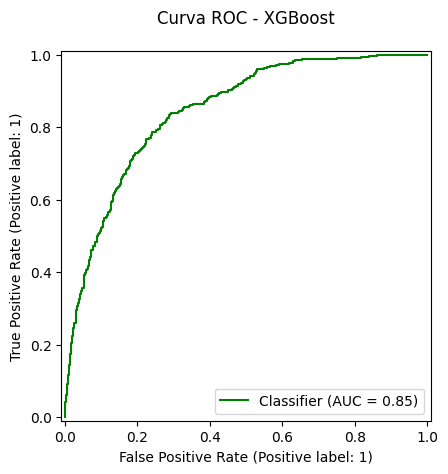

In [61]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

#Modelo XBGoots
xgb_model = XGBClassifier(n_estimators = 300,
                          learning_rate = 0.05,
                          max_depth = 5,
                          subsample = 0.8,
                          colsample_bytree = 0.8,
                          eval_metric = 'logloss',
                          random_state = 5)

#entrenamineto
xgb_model.fit(X_train_scaler, y_train)

#predicciones
y_xgb_pred = xgb_model.predict(X_test_scaler)
y_xgb_proba = xgb_model.predict_proba(X_test_scaler)[:,1]

#Métricas
print('Accuracy:', accuracy_score(y_test, y_xgb_pred))
print(classification_report(y_test, y_xgb_pred))

#Matriz de confusión
cm = confusion_matrix(y_test, y_xgb_pred)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['No Churn/continua', 'Churn/abandona'])

#Gráfico
visualizacion_dummy.plot(cmap = 'Greens')
plt.title('Matriz de confusión - XGBoost', pad = 20)
plt.show()

#curva ROC
RocCurveDisplay.from_predictions(y_test, y_xgb_proba, color = 'green')
plt.title('Curva ROC - XGBoost', pad = 20)
plt.savefig('graf9.png', dpi=300, bbox_inches='tight')
plt.show()

* Tiene una exactitud del 80
%

* 1174 clientes que continuan y el modelo predijo que permanecian.

* 236 clientes que abandonaron y el modelo predijo que abandonaban.

* 120 clientes que continuaron y el modelo predijo que abandonaban. **FALSOS POSITIVOS.**

* 231 clientes que abandonaron y el modelo predijo que continuaban. **FALSOS NEGATIVOS.**


**Curva ROC**

AUC = 0.85

El modelo tiene un 85% de probabilidad de asignar puntuación más alta a un cliente que sí abandona a uno que no abandona.

Detalles:
  - 1.0 -> modelo perfecto
  - 0.5 -> modelo aleatorio
  - 0.28 -> modelo peor que aleatorio.


##**Comparación de modelos**

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

#diccionario de modelos
modelos = {
    'Dummy': dummy,
    'Regresión Logística': reg_log,
    'Random Forest': random_forest,
    'Decision Tree Podado': arbol_decision,
    'XGBoost': xgb_model
}

resultados = []

for nombre, modelo in modelos.items():
    # Predicciones
    y_pred = modelo.predict(X_test_scaler)
    y_proba = modelo.predict_proba(X_test_scaler)[:, 1]

    # Métricas
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

# Convertir a DataFrame
df_comparacion = pd.DataFrame(resultados)
df_comparacion.round(2).style.highlight_max(
    subset=['Recall', 'AUC', 'F1-score'],
    color='pink')


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Dummy,0.730000,0.000000,0.000000,0.000000,0.500000
1,Regresión Logística,0.770000,0.540000,0.780000,0.640000,0.850000
2,Random Forest,0.790000,0.610000,0.600000,0.610000,0.830000
3,Decision Tree Podado,0.800000,0.630000,0.610000,0.620000,0.840000
4,XGBoost,0.800000,0.660000,0.510000,0.570000,0.850000


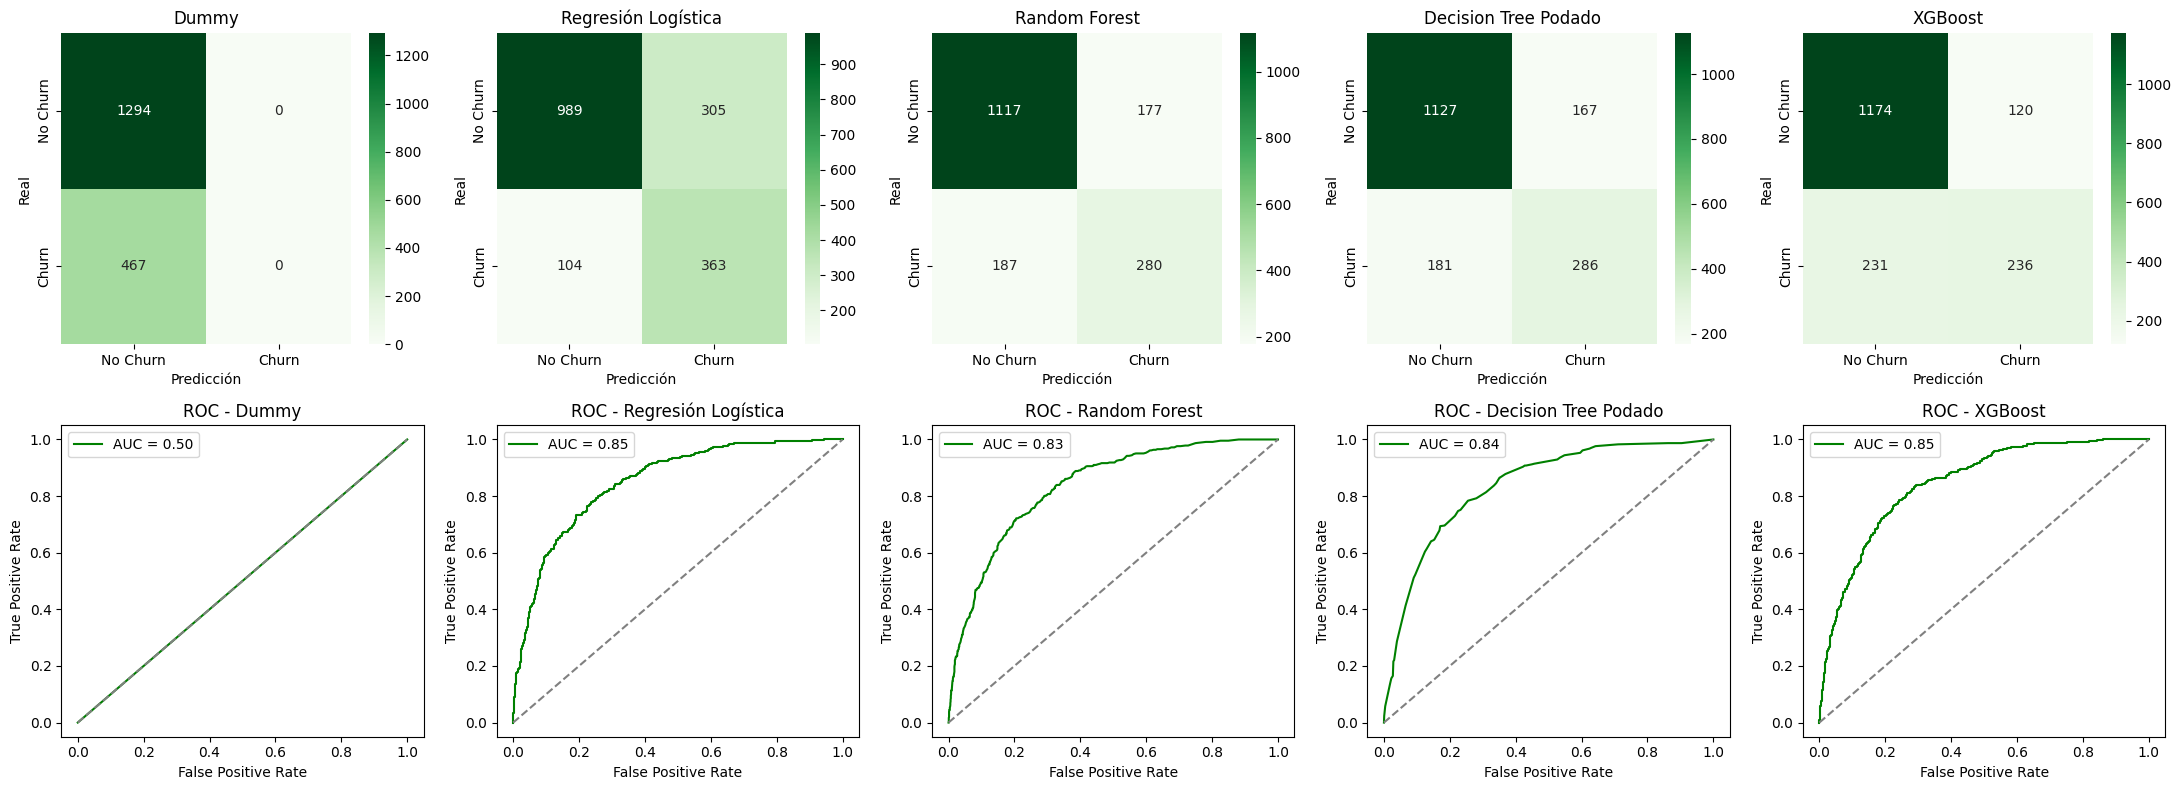

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

modelos = {
    'Dummy': dummy,
    'Regresión Logística': reg_log,
    'Random Forest': random_forest,
    'Decision Tree Podado': arbol_decision,
    'XGBoost': xgb_model
}

# Crear figura con 2 filas y 5 columnas
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

# Convertir a arreglo plano para iterar fácilmente
axes = axes.reshape(2, 5)

# FILA 1: MATRICES DE CONFUSIÓN

for idx, (nombre, modelo) in enumerate(modelos.items()):
    ax = axes[0, idx]  # fila 0, columna idx

    y_pred = modelo.predict(X_test_scaler)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=ax)

    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")


# FILA 2: CURVAS ROC

for idx, (nombre, modelo) in enumerate(modelos.items()):
    ax = axes[1, idx]  # fila 1, columna idx

    y_proba = modelo.predict_proba(X_test_scaler)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='green', label=f"AUC = {roc_auc:.2f}")
    ax.plot([0,1], [0,1], linestyle='--', color='gray')

    ax.set_title(f"ROC - {nombre}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.tight_layout()
plt.savefig('graf-final.png', dpi=300, bbox_inches='tight')
plt.show()

Las métricas más importantes para **Churn** son:
* Recall - El porcentaje de clientes que sí abandonan.

* F1_score - El balance entre:
  - precision - qué tan confiable es cuando predice "churn".
  - Recall - qué tanto detecta churn real.
  
* AUC - Área bajo la curva ROC, qué tan bien el modelo separa a los clientes que abandonan de los que no.
  - 0.50 - modelo aleatorio
  - 0.70 - 0.80 → aceptable
  - 0.80 - 0.90 → muy bueno
  - 0.90 + → excepcional

**Se determina que el modelo de Regresión Logística es el mejor modelo.**


##**Análisis de la Importancia de las Variables**

* Coeficiente positivo - aumenta probabilidad de churn/abandona.

* Coeficiente negativo - reduce la posibilidad de churn/continua.

In [47]:
#Importancia de variables es Regresión Logístia
import pandas as pd

coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': reg_log.coef_[0]
}).sort_values(by = 'Coeficiente', ascending = False)

coeficientes

,Variable,Coeficiente
25,remainder__account.Charges.Total,0.734710
2,onehotencoder__internet.InternetService_Fiber ...,0.571784
4,onehotencoder__account.Contract_Month-to-month,0.314519
22,remainder__internet.StreamingMovies,0.275108
16,remainder__phone.MultipleLines,0.252204
21,remainder__internet.StreamingTV,0.219980
23,remainder__account.PaperlessBilling,0.192255
9,onehotencoder__account.PaymentMethod_Electroni...,0.137022
19,remainder__internet.DeviceProtection,0.040945
11,remainder__customer.SeniorCitizen,0.028159


* Importancia alta - variables que más reducen impurezas.

In [48]:
#Importancia de variables es Random Forest

import pandas as pd

importancia_random_forest = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': random_forest.feature_importances_
}).sort_values(by = 'Importancia', ascending = False)

importancia_random_forest

,Variable,Importancia
14,remainder__customer.tenure,0.122632
25,remainder__account.Charges.Total,0.112574
24,remainder__account.Charges.Monthly,0.103854
26,remainder__Cuentas_Diarias,0.103827
4,onehotencoder__account.Contract_Month-to-month,0.099000
6,onehotencoder__account.Contract_Two year,0.042068
9,onehotencoder__account.PaymentMethod_Electroni...,0.035677
23,remainder__account.PaperlessBilling,0.032470
20,remainder__internet.TechSupport,0.031023
2,onehotencoder__internet.InternetService_Fiber ...,0.030642


Importancia basada en ganancias

In [49]:
#Importancia de variables con XGBoost

importancia_xgb = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': xgb_model.feature_importances_
}).sort_values(by = 'Importancia', ascending = False)

importancia_xgb

,Variable,Importancia
4,onehotencoder__account.Contract_Month-to-month,0.427419
2,onehotencoder__internet.InternetService_Fiber ...,0.129206
6,onehotencoder__account.Contract_Two year,0.045052
3,onehotencoder__internet.InternetService_No,0.038927
1,onehotencoder__internet.InternetService_DSL,0.035312
5,onehotencoder__account.Contract_One year,0.024277
9,onehotencoder__account.PaymentMethod_Electroni...,0.020698
22,remainder__internet.StreamingMovies,0.020018
21,remainder__internet.StreamingTV,0.019916
15,remainder__phone.PhoneService,0.018730


##**Conclusiones**

* El tipo de contrato es determinante para churn.
  - Mes a mes - alto riesgo.
  - Dos años - bajo riesgo.

* La antigüedad del cliente con la empresa es clave.

* Los cargos mensuales y totales influyen en el churn.
  - Cargos altos - mayor churn.

* El servicio de Internet tipo Fibra es un riesgo. Podría deberse a:
  - Costos altos.
  - Problemas del servicio.
  - Tiempo de instalación.

Los modelos coinciden en que los contratos mensuales generan poca antigüedad y si el cargo es alto generará un churn.
Los clientes con servicio de fibra óptica, son mayormente propensos a cancelar el servicio.

Se debe enforcar la retención en nuevos clientes, contratos flexibles (mes a mes) y costos altos mensules o totales.
